In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [2]:
# 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


문제 1 · 펭귄의 부리는 길수록 두꺼울까?

▸ 남극 팔머 기지에서 측정한 펭귄 344마리의 신체 데이터(penguins)를 사용합니다.

▸부리 길이(bill_length_mm)와 부리 두께(bill_depth_mm)가 함께 어떻게 움직이는지 봅니다.

▸그런데 이 데이터에는 세 종(Adelie·Chinstrap·Gentoo)이 섞여 있습니다. 전체를 뭉쳐서 볼 때와 집단을 나눠서 볼 때 결론이 정반대로 뒤집히는 일이 실제로 일어납니다.

🎯 이 문제로 배우는 것

▸상관계수를 계산하기 전에 산점도를 먼저 그려야 하는 이유를, 숫자로 직접 확인합니다.

Q1 · 산점도로 두 변수의 관계를 그려 봅시다

▸가로축 bill_length_mm, 세로축 bill_depth_mm로 산점도를 그리세요.

▸그래프 제목과 축 라벨을 한글로 알아보기 쉽게 설정하세요.

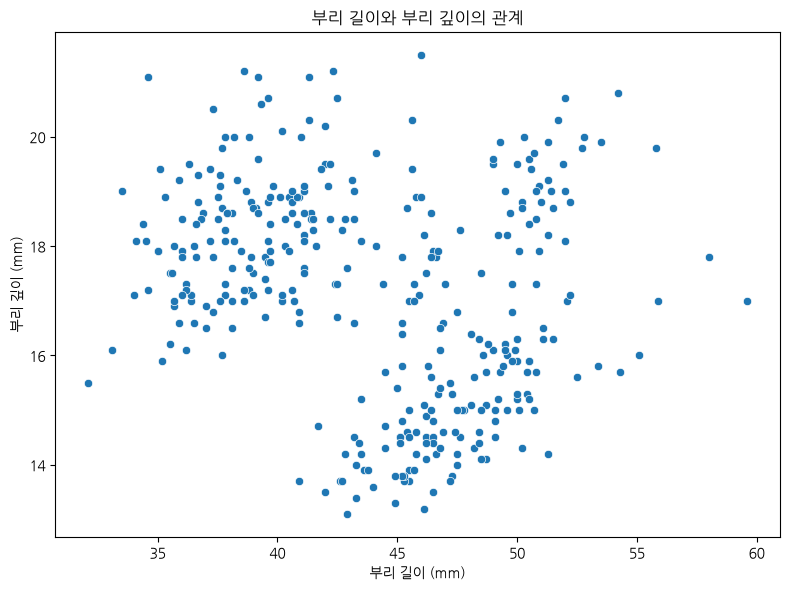

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm')
plt.title('부리 길이와 부리 깊이의 관계')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 깊이 (mm)')
plt.tight_layout()
plt.show()

Q2 · 종별로 색을 나눠 같은 그림을 다시 그려 봅시다

▸Q1과 똑같은 산점도에 펭귄의 종(species)별로 점의 색을 다르게 칠하세요.

▸Q1의 그림과 나란히 놓고 무엇이 달라 보이는지 관찰하세요.

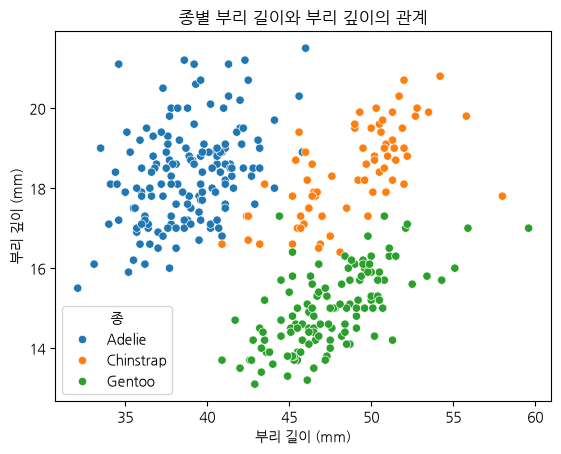

In [4]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('종별 부리 길이와 부리 깊이의 관계')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 깊이 (mm)')
plt.legend(title='종')
plt.show()

Q3 · 상관계수를 '전체'와 '종별'로 각각 구해 비교해 봅시다

▸두 변수의 상관계수를 전체 데이터에 대해 계산하세요.

▸같은 상관계수를 종별로 나누어 계산하세요.

▸두 결과의 부호를 비교하세요.

In [6]:
import pandas as pd

# 1. 전체 데이터 상관계수
overall_corr = penguins[['bill_length_mm', 'bill_depth_mm']].dropna().corr()
overall_value = overall_corr.loc['bill_length_mm', 'bill_depth_mm']
print("전체 상관계수:", overall_value)

# 2. 종별 상관계수
species_corr = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
print(species_corr)

# 3. 비교하기 좋은 표로 정리
result = pd.DataFrame({
    '집단': ['전체', 'Adelie', 'Chinstrap', 'Gentoo'],
    '상관계수': [
        overall_value,
        penguins[penguins['species']=='Adelie'][['bill_length_mm','bill_depth_mm']].corr().iloc[0,1],
        penguins[penguins['species']=='Chinstrap'][['bill_length_mm','bill_depth_mm']].corr().iloc[0,1],
        penguins[penguins['species']=='Gentoo'][['bill_length_mm','bill_depth_mm']].corr().iloc[0,1],
    ]
})
result['부호'] = result['상관계수'].apply(lambda x: '양(+)' if x > 0 else '음(-)')
print(result)

전체 상관계수: -0.23505287035553338
                          bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000
          집단      상관계수    부호
0         전체 -0.235053  음(-)
1     Adelie  0.391492  양(+)
2  Chinstrap  0.653536  양(+)
3     Gentoo  0.643384  양(+)


전체는 음의 방향, 종별로는 전부 양의 방향"이라는 부호 역전 현상

1) Q1 산점도의 방향, Q3 전체 상관계수와 부호가 일치하는가?
Q1의 산점도는 전체적으로 봤을 때 오른쪽 아래로 향하는 흐름 — 부리가 길수록 깊이가 얕아지는 것처럼 보였습니다. 실제로 Q3에서 계산한 전체 상관계수도 -0.235로 음수였으니, 그림에서 받은 인상과 숫자가 일치합니다. 즉 "전체로 보면 산점도 인상과 상관계수가 서로를 뒷받침"하는 상황이었죠.

2) 종별 상관계수는 전체와 부호가 같은가, 다른가?
정반대입니다. 전체는 -0.235(음)인데, Adelie(+0.391), Chinstrap(+0.654), Gentoo(+0.643) 세 종 모두 양수입니다. 부호가 완전히 뒤집혔습니다.

3) 왜 정반대 결론이 나왔는가 — 무엇이 착시를 만드는가?
핵심은 종마다 부리의 "기본 좌표"가 다르다는 점입니다. Q2 그림을 보면:

Adelie는 왼쪽 위(짧고 깊은 부리)에,
Gentoo는 오른쪽 아래(길고 얕은 부리)에,
Chinstrap은 오른쪽 위(길고 깊은 부리)에

각각 뭉쳐 있습니다. 종이라는 변수가 x축(길이)과 y축(깊이) 둘 다에 동시에 영향을 주기 때문에, 종을 무시하고 전체를 보면 "그룹 내부의 진짜 관계"가 아니라 "그룹들이 서로 어디에 위치하는가"가 상관계수를 지배해버립니다. 종은 여기서 교란변수(confounding variable) 역할을 하는 거죠. 이렇게 숨은 집단 변수 때문에 전체와 부분집합의 결론이 반대로 나오는 현상을 심슨의 역설(Simpson's Paradox) 이라고 부릅니다.

4) '종' 정보가 없었다면 어떤 잘못된 결론을 내렸을까?
종 컬럼이 없었다면 "부리 길이와 부리 깊이는 음의 관계다 — 부리가 길수록 얕아진다"는 결론을 그대로 받아들였을 겁니다. 하지만 실제로는 종 내부에서는 정반대로 양의 관계가 존재하므로, 이는 완전히 잘못된 방향의 결론이 됩니다. 결론의 형태로 정리하면:

종을 무시하면 → "음의 상관관계"
종을 고려하면 → "각 종 내에서는 양의 상관관계"

이 사례는 왜 EDA에서 그룹 변수가 있는지부터 먼저 확인하고, 전체 통계량만으로 성급하게 결론 내리면 안 되는지를 잘 보여주는 예시입니다.

문제 2 · 날개가 길면 몸무게도 무거울까? — 관계를 숫자로
난이도 하 · 예상 20분

📖 상황

▸ 문제 1에서 "숫자 전에 그림"을 배웠습니다. 이제 관계를 숫자 하나로 요약해 봅니다.

▸ 이번에는 **날개 길이(flipper_length_mm)와 몸무게(body_mass_g)**를 봅니다. 이 두 변수는 문제 5까지 계속 사용하며, 상관 → 회귀 → 검정 → 진단으로 이어집니다.

▸**피어슨 상관계수(r)**는 관계의 방향(부호)과 강도(절대값)를 −1~+1로 나타냅니다. 다만 피어슨은 두 변수가 정규분포라는 전제에 기대는 모수적 방법입니다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


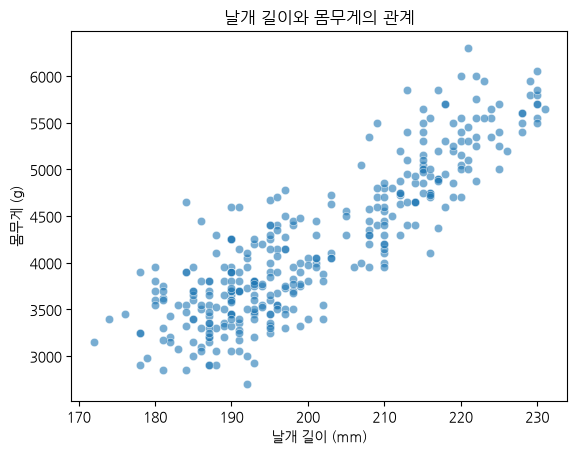

In [7]:
# 데이터 준비 — 실행만 하세요
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

Q1 · 피어슨의 전제인 정규성을 점검해 봅시다

▸flipper_length_mm과 body_mass_g 각각에 대해 정규성 검정(Shapiro-Wilk)을 수행하세요.

▸유의수준 0.05를 기준으로 '정규성을 기각하는지'까지 함께 출력하세요.

In [8]:
from scipy import stats

alpha = 0.05

for col in ['flipper_length_mm', 'body_mass_g']:
    stat, p_value = stats.shapiro(df_corr[col])
    result = "기각한다 (정규성 없음)" if p_value < alpha else "기각하지 못한다 (정규성 있음)"
    print(f"[{col}] W = {stat:.4f}, p-value = {p_value:.4f} → 정규성을 {result}")

[flipper_length_mm] W = 0.9515, p-value = 0.0000 → 정규성을 기각한다 (정규성 없음)
[body_mass_g] W = 0.9592, p-value = 0.0000 → 정규성을 기각한다 (정규성 없음)


Q2 · 피어슨 상관계수와 p-값을 함께 구해 봅시다

▸상관계수만이 아니라 p-값도 함께 구하세요. 상관계수도 가설검정의 대상입니다.

▸결과는 반드시 r, p_value라는 이름으로 저장하세요. 문제 3·4에서 이어서 사용합니다.

In [10]:
from scipy import stats

r, p_value = stats.pearsonr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

alpha = 0.05
result = "기각한다 (상관관계가 유의하다)" if p_value < alpha else "기각하지 못한다 (상관관계가 유의하지 않다)"

print(f"피어슨 상관계수 r = {r:.4f}")
print(f"p-value = {p_value:.4e}")
print(f"유의수준 {alpha} 기준: 귀무가설(r=0)을 {result}")

피어슨 상관계수 r = 0.8712
p-value = 4.3707e-107
유의수준 0.05 기준: 귀무가설(r=0)을 기각한다 (상관관계가 유의하다)


Q3 · 스피어만 상관계수를 구해 피어슨과 비교해 봅시다

▸스피어만 상관계수(ρ)를 구하세요.

▸Q2의 피어슨 값과 나란히 출력해 두 값의 차이를 눈으로 확인하세요.

In [11]:
from scipy import stats

# Q2 피어슨
r, p_value = stats.pearsonr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

# Q3 스피어만
rho, p_value_spearman = stats.spearmanr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

alpha = 0.05
result_pearson = "기각한다 (상관관계가 유의하다)" if p_value < alpha else "기각하지 못한다 (상관관계가 유의하지 않다)"
result_spearman = "기각한다 (상관관계가 유의하다)" if p_value_spearman < alpha else "기각하지 못한다 (상관관계가 유의하지 않다)"

print("=== 피어슨 (모수) ===")
print(f"r   = {r:.4f}, p-value = {p_value:.4e}")
print(f"유의수준 {alpha} 기준: 귀무가설(r=0)을 {result_pearson}")
print()
print("=== 스피어만 (비모수) ===")
print(f"rho = {rho:.4f}, p-value = {p_value_spearman:.4e}")
print(f"유의수준 {alpha} 기준: 귀무가설(rho=0)을 {result_spearman}")
print()
print("=== 차이 ===")
print(f"r - rho = {r - rho:.4f}")

=== 피어슨 (모수) ===
r   = 0.8712, p-value = 4.3707e-107
유의수준 0.05 기준: 귀무가설(r=0)을 기각한다 (상관관계가 유의하다)

=== 스피어만 (비모수) ===
rho = 0.8400, p-value = 2.7632e-92
유의수준 0.05 기준: 귀무가설(rho=0)을 기각한다 (상관관계가 유의하다)

=== 차이 ===
r - rho = 0.0312


Q4 · 세 결과를 종합해 관계를 문장으로 정리해 봅시다

▸Q1~Q3의 결과를 근거로, 오른쪽 빈칸을 채워 관계를 정리하세요.

▸숫자만 적지 말고 그 숫자가 뜻하는 바를 함께 쓰세요.

Shapiro-Wilk 검정 결과 flipper_length_mm(p < 0.001)과 body_mass_g(p < 0.001) 모두 정규성이 기각되었다. 

그러나 피어슨 상관계수(r = 0.871)와 스피어만 상관계수(ρ = 0.840)의 차이가 크지 않아, 정규성 위반이 상관관계 해석에 실질적인 영향을 주지 않는다고 판단했다. 

따라서 피어슨 상관계수를 그대로 사용해도 무방하며, 날개 길이와 몸무게 사이에는 매우 강한 양의 상관관계(r = 0.871) 가 존재한다. 

이 관계는 통계적으로도 유의하다(p < 0.001, α = 0.05에서 귀무가설 기각). 

즉, 날개가 길수록 몸무게도 무거운 경향이 뚜렷하며, 이 패턴이 표본 오차로 우연히 나타났을 가능성은 극히 낮다.

1) 정규성이 기각됐다고 피어슨을 쓰면 안 되는가?

"쓰면 안 되나"가 아니라 "결론이 바뀌는가"를 물어야 합니다. Q2의 피어슨(r=0.871)과 Q3의 스피어만(ρ=0.840)은 차이가 0.031에 불과했습니다. 

두 값이 이렇게 가깝다는 건 정규성 위반이 상관 추정치를 왜곡할 정도로 심각하지 않다는 뜻입니다. 

따라서 이 경우엔 피어슨을 그대로 써도 결론에 실질적인 문제가 없다고 판단할 수 있습니다. 

다만 이건 "정규성 위반을 무시해도 된다"는 일반 원칙이 아니라, 이 데이터에 한해 확인을 거쳐 내린 판단이라는 점이 중요합니다.

2) 피어슨과 스피어만이 비슷하다는 것의 의미 / 크게 달랐다면?

두 값이 비슷하다는 건 관계가 이상치 몇 개에 좌우되지 않고, 대체로 선형에 가까운 형태로 안정적으로 존재한다는 뜻입니다. 반대로 두 값이 크게 벌어졌다면 다음을 의심해야 합니다:

이상치가 몇 개 존재해서 피어슨(평균 기반)만 심하게 흔들렸을 가능성

관계가 비선형이라 피어슨은 못 잡아내고, 순위 기반인 스피어만만 관계를 포착했을 가능성

3) Q2의 p-값은 무엇에 대한 검정인가? "크다"와 "유의하다"는 같은 말인가?

Q2의 p-value는 "모집단의 상관계수가 정확히 0이다"라는 귀무가설에 대한 검정입니다. 

즉 관계가 존재하는지(유무) 를 묻는 것이지, 관계가 얼마나 강한지(크기) 를 묻는 게 아닙니다.

"상관계수가 크다"와 "유의하다"는 전혀 다른 말입니다. 

표본 크기가 크면 r=0.05처럼 아주 약한 상관도 p-value가 작게 나와 "유의하다"고 나올 수 있고, 반대로 표본이 작으면 r=0.5처럼 꽤 강한 상관도 유의하지 않게 나올 수 있습니다. 

이번 사례는 r도 크고(0.871) p-value도 작아서 두 가지가 우연히 같은 방향을 가리켰을 뿐, 원래는 분리해서 봐야 하는 별개의 질문입니다.

4) '날개가 길어지는 것이 몸무게를 무겁게 만드는 원인이다'라고 할 수 있는가?

이런 인과 진술은 상관계수만으로는 정당화되지 않습니다. 세 갈래로 나눠보면:

- 교란변수(confounding): 문제 1에서 이미 만났던 종(species) 이 유력한 후보입니다. 

Gentoo는 원래 몸집 자체가 크고 날개도 깁니다. 

즉 "날개 길이 → 몸무게"가 아니라 "종 → 날개 길이"이면서 동시에 "종 → 몸무게"인 구조일 수 있습니다. 

종을 통제하지 않으면 이 둘의 관계가 실제보다 부풀려 보일 수 있습니다.

- 역인과(reverse causation): 생물학적으로는 날개가 몸무게를 결정한다기보다, 성장 과정에서 골격 크기(날개 포함)와 체중이 함께 커지는 것에 가깝습니다. 

즉 "몸무게가 늘어서 날개도 길어진다"는 방향도 논리적으로 배제하기 어렵습니다.

- 우연(chance): 이 경우는 가능성이 낮습니다. p-value가 극히 작고(4.37×10⁻¹⁰⁷) 표본 크기도 342로 충분히 크기 때문에, 이 강한 관계가 순전히 우연히 나타났을 가능성은 사실상 배제할 수 있습니다.


=> 결론적으로, 우연은 배제할 수 있지만 교란변수(종)와 역인과 가능성은 남아 있어 이 상관관계만으로 인과를 주장하기엔 근거가 부족합니다. 

이 관계를 인과로 해석하려면 종을 통제한 다항회귀나, 성장 시점별 데이터를 활용한 분석이 추가로 필요합니다.

문제 3 · 그 관계를 하나의 식으로 만들 수 있을까?
난이도 중 · 예상 25분

📖 상황

▸
상관계수는 "관계가 얼마나 강한가"만 알려주고, "날개가 1mm 길면 몸무게가 몇 g 늘어나는가"는 말해주지 않습니다. 그 답을 주는 것이 **선형회귀(Linear Regression)**입니다.

▸
흩어진 점들을 가장 잘 가로지르는 직선 y = a + bx를 찾아 관계를 하나의 식으로 표현합니다. a(절편)는 x가 0일 때의 예측값, b(기울기)는 x가 1 늘 때 y가 평균적으로 변하는 양입니다.

▸
그런데 상관과 회귀는 서로 남이 아닙니다. 문제 2에서 구한 r과 이번에 구할 기울기·결정계수 사이에는 정확한 관계식이 성립합니다.

🎯 이 문제로 배우는 것

▸
회귀식을 적합·해석하고, 상관과 회귀가 한 뿌리임을 숫자로 확인합니다.

In [12]:
# 데이터 준비 — 실행만 하세요
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


Q1 · 단순회귀 모델을 적합해 봅시다

▸
날개 길이(설명변수) → 몸무게(반응변수) 회귀 모델을 적합하세요.

▸
적합한 모델은 반드시 model이라는 이름으로 저장하세요. 문제 4·5에서 이어서 사용합니다.

In [13]:
import statsmodels.formula.api as smf

model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=penguins_cleaned).fit()

print("모델 적합 완료")
print(f"절편(Intercept): {model.params['Intercept']:.4f}")
print(f"기울기(flipper_length_mm): {model.params['flipper_length_mm']:.4f}")
print(f"R-squared: {model.rsquared:.4f}")

모델 적합 완료
절편(Intercept): -5780.8314
기울기(flipper_length_mm): 49.6856
R-squared: 0.7590


Q2 · 분석 결과표를 출력해 봅시다

▸
적합한 모델의 요약 결과표를 출력하세요.

▸
coef, P>|t|, R-squared 열이 각각 어디에 있는지 눈으로 찾아 두세요. 다음 문제들에서 계속 씁니다.


In [14]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        12:39:59   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

Q3 · 회귀식을 완성해 봅시다

▸
Q2의 결과표에서 절편과 기울기를 찾아 오른쪽 빈칸을 채우세요.

▸
숫자를 옮겨 적은 뒤, 완성된 식을 한 줄로 써 보세요.

In [15]:
intercept = model.params['Intercept']
slope = model.params['flipper_length_mm']

print(f"절편(a) = {intercept:.4f}")
print(f"기울기(b) = {slope:.4f}")
print(f"회귀식: body_mass_g = {intercept:.2f} + {slope:.2f} × flipper_length_mm")

절편(a) = -5780.8314
기울기(b) = 49.6856
회귀식: body_mass_g = -5780.83 + 49.69 × flipper_length_mm


Q4 · 회귀식으로 예측해 봅시다

▸
날개 길이가 평균보다 10mm 더 긴 펭귄은, 평균적인 펭귄보다 몸무게가 몇 g 더 무거울까요?

▸
계산 결과를 단위(g)와 함께 출력하세요.

In [16]:
slope = model.params['flipper_length_mm']

mass_increase = slope * 10

print(f"기울기(b) = {slope:.4f} g/mm")
print(f"날개 길이가 평균보다 10mm 더 긴 펭귄은, 평균보다 약 {mass_increase:.2f}g 더 무겁다.")

기울기(b) = 49.6856 g/mm
날개 길이가 평균보다 10mm 더 긴 펭귄은, 평균보다 약 496.86g 더 무겁다.


Q5 · 상관과 회귀를 잇는 두 관계식을 확인해 봅시다

▸ 다음 두 식이 실제로 성립하는지 숫자로 확인하세요.

▸ ① 기울기 = r × (y의 표준편차 / x의 표준편차)

▸ ② 결정계수 R² = r² (단순회귀에서만 성립)

▸ 좌변과 우변을 나란히 출력해 두 값이 일치하는지 눈으로 확인하세요.

In [17]:
from scipy import stats

r, p_value = stats.pearsonr(penguins_cleaned['flipper_length_mm'], penguins_cleaned['body_mass_g'])

# ① 기울기 = r × (y의 표준편차 / x의 표준편차)
std_y = penguins_cleaned['body_mass_g'].std(ddof=1)
std_x = penguins_cleaned['flipper_length_mm'].std(ddof=1)

slope_from_r = r * (std_y / std_x)
slope_from_model = model.params['flipper_length_mm']

print("=== ① 기울기 = r × (표준편차 비율) ===")
print(f"좌변 (model 기울기)        = {slope_from_model:.6f}")
print(f"우변 (r × std_y/std_x)     = {slope_from_r:.6f}")
print(f"일치 여부: {abs(slope_from_model - slope_from_r) < 1e-6}")

# ② R² = r²
r_squared_from_r = r ** 2
r_squared_from_model = model.rsquared

print("\n=== ② R² = r² ===")
print(f"좌변 (model.rsquared)      = {r_squared_from_model:.6f}")
print(f"우변 (r²)                  = {r_squared_from_r:.6f}")
print(f"일치 여부: {abs(r_squared_from_model - r_squared_from_r) < 1e-6}")

=== ① 기울기 = r × (표준편차 비율) ===
좌변 (model 기울기)        = 49.685566
우변 (r × std_y/std_x)     = 49.685566
일치 여부: True

=== ② R² = r² ===
좌변 (model.rsquared)      = 0.758993
우변 (r²)                  = 0.758993
일치 여부: True


1) 기울기(b)를 문장으로 풀어 쓰기

"날개 길이가 1mm 길어질 때, 몸무게는 평균적으로 약 49.69g 증가한다."

2) 절편(a) = -5780.83을 "날개 길이 0mm인 펭귄의 몸무게"로 해석해도 되는가?

안 됩니다. 회귀식은 관측된 데이터 범위 안에서만 의미를 가집니다. 

이 데이터에서 날개 길이는 172mm~231mm 사이에 분포하는데, 0mm는 이 범위를 한참 벗어난 값입니다. 

애초에 날개 길이가 0mm인 펭귄은 존재할 수 없으므로, 절편 자체를 물리적으로 해석하려 들면 안 됩니다. 

절편은 어디까지나 직선을 수학적으로 정의하기 위한 값이지, "실제로 있을 수 있는 상황"을 나타내는 값이 아닙니다. 

이렇게 관측 범위 밖으로 예측을 확장하는 것을 **외삽(extrapolation)**이라 부르고, 회귀분석에서 조심해야 할 대표적인 함정입니다.

3) x와 y를 바꾸면 기울기와 R²는 각각 같을까, 다를까?

직접 확인해보면:

모델	기울기	R²

body_mass_g ~ flipper_length_mm	49.6856 (g/mm)	0.7590

flipper_length_mm ~ body_mass_g	0.015276 (mm/g)	0.7590

R²는 같고, 기울기는 다릅니다.

이유는 관계식 ①②에서 바로 나옵니다:

② R² = r²에서 r은 x, y를 바꿔도 값이 그대로인 대칭적인 양입니다(상관계수는 애초에 방향성이 없는 개념). 그래서 R²도 어느 쪽을 종속변수로 놓든 항상 같습니다.

① 기울기 = r × (s_y/s_x)에서 표준편차 비율(s_y/s_x)은 비대칭입니다. x, y를 바꾸면 이 비율이 역수가 되므로(정확히는 역수는 아니고 별개의 값이지만, 대칭이 깨짐), 기울기도 달라집니다. 

실제로 49.6856과 0.015276은 서로 역수 관계가 아니라 각각 "y의 변동을 x로 나눈 것"과 "x의 변동을 y로 나눈 것"이라는, 애초에 다른 질문에 대한 답이기 때문입니다.

즉 "관계의 강도(R², r)"는 대칭이지만, "한쪽이 다른 쪽을 얼마나 예측하는가(기울기)"는 방향에 따라 달라진다는 걸 보여주는 좋은 예시입니다.

4) 회귀가 상관보다 더 알려주는 것은 무엇인가?

상관계수 r은 "관계가 얼마나 강한가(강도)"만 알려주는 단위 없는 지표입니다. 

반면 회귀의 기울기 b는 "x가 1단위 늘어날 때 y가 실제로 몇 단위 변하는가(변화량)"를 구체적인 단위(mm당 g)로 알려줍니다.

즉, r=0.871이라고만 하면 "꽤 강한 관계가 있다"는 정도만 알 수 있지만, 

보고서에 "날개 길이가 1mm 길어질 때마다 몸무게가 약 49.69g 늘어난다"처럼 실질적이고 구체적인 예측 문장을 쓸 수 있는 건 회귀 쪽입니다. 

상관은 관계의 "존재와 세기"를, 회귀는 거기에 더해 "얼마나(정량적 크기)"까지 답해준다는 점이 핵심 차이입니다.

문제 4 · 이 기울기, 우연이 아니라고 말할 수 있을까?
난이도 중 · 예상 25분

📖 상황

▸
문제 3에서 기울기를 구했습니다. 그런데 이 값은 표본 342마리에서 계산된 값입니다.

▸
만약 전체 펭귄 집단에서 두 변수가 실제로는 아무 관계가 없다면(기울기 = 0), 우리가 얻은 기울기는 그저 표본을 뽑는 과정에서 우연히 생긴 값일 수도 있습니다.

▸
이 의심에 답하는 것이 회귀계수의 가설검정이고, 결과표의 P>|t| 열이 판단 근거입니다.

🎯 이 문제로 배우는 것

▸
강의에서 배운 상관계수의 유의성 검정과 회귀계수 검정이 같은 검정임을 확인하고, p-값이 항상 작게 나오는 것은 아니라는 사실을 기각 실패 사례로 직접 만납니다.

In [18]:
# 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행 (문제 3과 동일)")
print("설명변수: flipper_length_mm  /  반응변수: body_mass_g")

분석 대상 데이터: 342 행 (문제 3과 동일)
설명변수: flipper_length_mm  /  반응변수: body_mass_g


Q1 · 가설을 세워 봅시다

▸
회귀계수(기울기)에 대한 귀무가설(H₀)과 대립가설(H₁)을 오른쪽 빈칸에 쓰세요.

▸
'기울기'가 무엇과 같은지/다른지를 명확히 적으세요.

body_mass_g=β0​ + β₁×flipper_length_mm

에서, 기울기 계수 β₁에 대해:

귀무가설 H₀: β₁ = 0
→ "모집단에서 날개 길이는 몸무게와 아무런 선형 관계가 없다 (날개 길이가 변해도 몸무게는 평균적으로 변하지 않는다)."

대립가설 H₁: β₁ ≠ 0
→ "모집단에서 날개 길이는 몸무게와 선형 관계가 있다 (날개 길이가 변하면 몸무게도 평균적으로 변한다)."

Q2 · 기울기의 p-값을 찾아 봅시다

▸
flipper_length_mm 행에서 P>|t| 열의 값을 찾아 출력하세요.

In [20]:
p_value_slope = model.pvalues['flipper_length_mm']
print(f"flipper_length_mm의 P>|t| = {p_value_slope:.4e}")

flipper_length_mm의 P>|t| = 4.3707e-107


Q3 · 유의수준 0.05로 결론을 내려 봅시다

▸
p-값과 유의수준 alpha = 0.05를 비교해, 판정 결과를 문장으로 출력하는 코드를 작성하세요.

▸
숫자만 찍지 말고 "기각한다 / 기각하지 못한다"까지 출력되도록 만드세요.

In [21]:
p_value_slope = model.pvalues['flipper_length_mm']
alpha = 0.05

result = "기각한다 (기울기가 0이 아니라고 볼 수 있다)" if p_value_slope < alpha else "기각하지 못한다 (기울기가 0이 아니라고 볼 근거가 부족하다)"

print(f"p-value = {p_value_slope:.4e}")
print(f"유의수준 alpha = {alpha}")
print(f"판정: 귀무가설(H0: 기울기 = 0)을 {result}")

p-value = 4.3707e-107
유의수준 alpha = 0.05
판정: 귀무가설(H0: 기울기 = 0)을 기각한다 (기울기가 0이 아니라고 볼 수 있다)


Q4 · 상관계수의 검정과 같은 검정인지 확인해 봅시다

▸
강의에서 배운 공식으로 t-통계량을 직접 계산하세요.

t = r × √(n − 2) / √(1 − r²)

▸
이 값을 model.tvalues['flipper_length_mm']와 나란히 출력해 비교하세요.

In [22]:
from scipy import stats
import numpy as np

r, _ = stats.pearsonr(penguins_cleaned['flipper_length_mm'], penguins_cleaned['body_mass_g'])
n = len(penguins_cleaned)

# 공식으로 직접 계산한 t
t_from_formula = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# 모델에서 가져온 t
t_from_model = model.tvalues['flipper_length_mm']

print(f"n = {n}, r = {r:.4f}")
print(f"공식으로 계산한 t   = {t_from_formula:.6f}")
print(f"model.tvalues[...]  = {t_from_model:.6f}")
print(f"두 값 일치 여부: {np.isclose(t_from_formula, t_from_model)}")

n = 342, r = 0.8712
공식으로 계산한 t   = 32.722234
model.tvalues[...]  = 32.722234
두 값 일치 여부: True


Q5 · p-값이 크게 나오는 사례를 만나 봅시다

▸
Adelie 종 수컷만 골라, bill_length_mm으로 body_mass_g를 설명하는 회귀를 적합하세요.

▸
기울기의 p-값을 유의수준 0.05와 비교하고, 표본 크기(n)와 R²도 함께 출력하세요.

In [23]:
subset = penguins.dropna(subset=['bill_length_mm', 'body_mass_g', 'species', 'sex'])
adelie_male = subset[(subset['species'] == 'Adelie') & (subset['sex'] == 'Male')]

model_adelie = smf.ols(formula='body_mass_g ~ bill_length_mm', data=adelie_male).fit()

n = len(adelie_male)
p_value_slope = model_adelie.pvalues['bill_length_mm']
r_squared = model_adelie.rsquared
alpha = 0.05

result = "기각한다 (기울기가 0이 아니라고 볼 수 있다)" if p_value_slope < alpha else "기각하지 못한다 (기울기가 0이 아니라고 볼 근거가 부족하다)"

print(f"표본 크기 n = {n}")
print(f"기울기 = {model_adelie.params['bill_length_mm']:.4f}")
print(f"p-value = {p_value_slope:.4f}")
print(f"R-squared = {r_squared:.4f}")
print(f"유의수준 {alpha} 기준: 귀무가설(H0: 기울기=0)을 {result}")

표본 크기 n = 73
기울기 = 33.5628
p-value = 0.0610
R-squared = 0.0486
유의수준 0.05 기준: 귀무가설(H0: 기울기=0)을 기각하지 못한다 (기울기가 0이 아니라고 볼 근거가 부족하다)


1) p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가? "귀무가설이 참일 확률"이라 해도 되는가?

p-value는 "귀무가설(H₀)이 참이라고 가정했을 때, 우리가 관측한 것과 같거나 더 극단적인 결과가 나올 확률" 입니다.

"귀무가설이 참일 확률"이라고 말하면 안 됩니다. 이건 조건과 결론의 방향을 뒤집은 흔한 오해예요.

맞는 표현: P(이런 데이터 | H₀가 참)

틀린 표현: P(H₀가 참 | 이런 데이터)

p-value는 데이터를 조건으로 H₀의 확률을 알려주는 값이 아니라, H₀를 가정한 세계에서 지금 우리가 관측한 정도의 결과가 얼마나 흔한/드문 일인지를 알려주는 값입니다. 

p-value=4.37e-107이라는 건 "H₀(기울기=0)가 맞다면, 342마리 표본에서 이 정도로 강한 관계가 우연히 나타날 확률이 사실상 0에 가깝다"는 뜻이지, "H₀가 참일 확률이 4.37e-107"이라는 뜻이 아닙니다.

2) Q4에서 두 t값이 일치했다는 것은 무엇을 뜻하는가?

단순회귀(설명변수가 하나)에서는 "상관계수 r이 0인지" 검정하는 것과 "회귀계수(기울기) β₁이 0인지" 검정하는 것이 수학적으로 완전히 동일한 검정이라는 뜻입니다. 

겉보기엔 서로 다른 두 방법(피어슨 상관 검정, 회귀계수 t검정)처럼 보이지만, 결국은 "두 변수 사이에 선형 관계가 있는가"라는 하나의 질문을 표현만 다르게 한 것이라, 

t-통계량도 p-value도 자동으로 똑같이 나올 수밖에 없습니다.

3) Q5의 결과는 Q2와 어떻게 달랐는가 — 표본 크기와 R² 측면에서

구분	Q2 (전체)	Q5 (Adelie 수컷만)
n	342	73
R²	0.759	0.049
p-value	≈0 (극히 작음)	0.061
판정	기각	기각 실패

두 가지가 동시에 작용했습니다.

표본 크기 감소: n이 342에서 73으로 줄어들면서 t-통계량의 분모가 커지는 효과가 생겨, 같은 크기의 관계라도 통계적으로 유의하다고 판정받기 더 어려워집니다.

관계 자체가 약함: R²=0.049는 bill_length_mm이 body_mass_g 변동의 5%도 설명하지 못한다는 뜻입니다. 

애초에 Adelie 수컷 안에서는 부리 길이와 몸무게의 관계가 원래도 약했던 것으로 보입니다(아마 종을 나눠 보면 개체 간 몸무게 차이의 주된 요인이 부리 길이보다는 다른 변수일 가능성이 높습니다).

즉 "표본이 작아져서" + "관계 자체가 약해서"라는 두 이유가 겹쳐 유의성이 사라진 사례입니다.

4) p-값이 0.05보다 조금 큰 경우, "관계가 없음이 증명됐다"고 할 수 있는가?

아닙니다. 정확한 표현은 "관계가 있다는 증거가 부족하다(기각 실패)" 이지, **"관계가 없다는 것이 증명됐다"**가 아닙니다.

이 둘은 완전히 다른 주장입니다:

기각 실패 = "이 표본으로는 H₀를 기각할 만큼 충분한 증거를 찾지 못했다"
"관계가 없음 증명" = "모집단에 실제로 관계가 없다는 것을 확정적으로 보였다"

가설검정은 애초에 "무죄 추정"과 비슷한 구조라, H₀를 기각하지 못했다고 해서 H₀가 참이라고 증명된 게 아닙니다. 특히 이번 경우처럼 n=73으로 표본이 작으면, 실제로는 약한 관계가 존재하더라도 그걸 탐지할 통계적 검정력(power)이 부족해서 기각에 실패했을 가능성이 큽니다. 그래서 정확한 결론은 "이 표본(n=73)으로는 부리 길이와 몸무게 사이에 유의한 선형 관계가 있다고 말할 만한 충분한 증거를 찾지 못했다" 정도로 조심스럽게 써야 합니다.

문제 5 · 미니 프로젝트 — 이 회귀모형, 믿고 보고해도 될까?
난이도 상 · 예상 35분

📖 상황

▸
계수가 유의하다고 해서 분석이 끝난 것은 아닙니다. 보고서를 쓰기 전에 두 가지를 더 확인합니다.

▸
① 얼마나 설명하는가 — 결정계수(R²) 반응변수 전체 변동 중 이 모델이 설명한 비율입니다.

▸
② 전제가 지켜졌는가 — 잔차(Residual) 진단 잔차는 실제값 − 예측값입니다. 좋은 모델이라면 잔차가 패턴 없이 0 주위에 고르게 흩어져야 합니다. 깔때기(부채꼴) 모양이면 등분산성이 깨졌다는 신호이고, 이때는 p-값과 신뢰구간을 그대로 믿기 어렵습니다.

🎯 이 문제로 배우는 것

▸
우리 모형을 진단한 뒤, 일부러 문제가 있는 다른 모형과 나란히 놓고 비교합니다. "통과한 잔차"만 보면 진단을 왜 하는지 알 수 없기 때문입니다.

In [24]:
# 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

분석 대상 데이터: 342 행
모형: body_mass_g ~ flipper_length_mm


Q1 · 결정계수로 설명력을 평가해 봅시다

▸
모델의 R-squared 값을 출력하세요.

▸
그 값이 뜻하는 바를 "몸무게 변동의 몇 %" 형태로 오른쪽 빈칸에 쓰세요.

In [25]:
r_squared = model.rsquared
print(f"R-squared = {r_squared:.4f}")
print(f"해석: 날개 길이(flipper_length_mm)는 몸무게(body_mass_g) 변동의 약 {r_squared*100:.1f}%를 설명한다.")

R-squared = 0.7590
해석: 날개 길이(flipper_length_mm)는 몸무게(body_mass_g) 변동의 약 75.9%를 설명한다.


Q2 · 예측값과 잔차를 계산해 봅시다

▸
모델의 예측값과 잔차를 각각 계산해 변수에 저장하세요.

▸
잔차의 개수와 평균을 함께 출력해, 잔차가 0 주위에 모여 있는지 확인하세요.

In [26]:
fitted_values = model.fittedvalues
residuals = model.resid

print(f"잔차 개수 = {len(residuals)}")
print(f"잔차 평균 = {residuals.mean():.10f}")

잔차 개수 = 342
잔차 평균 = 0.0000000000


Q3 · 잔차 산점도를 그려 봅시다

▸
가로축을 예측값, 세로축을 잔차로 하는 산점도를 그리세요.

▸
y = 0 기준선을 함께 표시하면 패턴을 보기 쉽습니다.

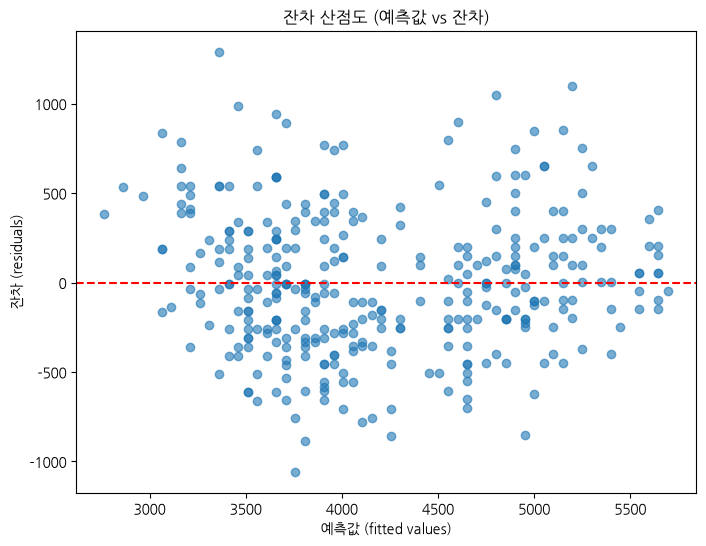

In [27]:
fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("잔차 산점도 (예측값 vs 잔차)")
plt.xlabel("예측값 (fitted values)")
plt.ylabel("잔차 (residuals)")
plt.show()

Q4 · 등분산성을 숫자로 검정해 봅시다

▸
브루쉬-페이건 검정으로 등분산성을 확인하세요.

▸
H₀는 "등분산이다"입니다. p-값이 0.05보다 작으면 이분산을 의심합니다.

▸
판정 결과를 문장으로 함께 출력하세요.

In [28]:
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = model.resid

lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals, model.model.exog)

alpha = 0.05
result = "기각한다 (이분산이 의심된다)" if lm_pvalue < alpha else "기각하지 못한다 (등분산 가정에 문제가 없다고 볼 수 있다)"

print(f"LM 통계량 = {lm_stat:.4f}")
print(f"LM p-value = {lm_pvalue:.4f}")
print(f"F 통계량 = {f_stat:.4f}")
print(f"F p-value = {f_pvalue:.4f}")
print()
print(f"유의수준 {alpha} 기준: 귀무가설(H0: 등분산이다)을 {result}")

LM 통계량 = 2.1579
LM p-value = 0.1418
F 통계량 = 2.1589
F p-value = 0.1427

유의수준 0.05 기준: 귀무가설(H0: 등분산이다)을 기각하지 못한다 (등분산 가정에 문제가 없다고 볼 수 있다)


Q5 · 문제가 있는 모형과 나란히 비교해 봅시다

▸
비교군으로 body_mass_g ~ bill_length_mm 모형을 적합해 model_bill로 저장하세요.

▸
두 모형의 잔차 산점도를 나란히 그리세요.

▸
두 모형의 브루쉬-페이건 p-값을 함께 출력해 비교하세요.

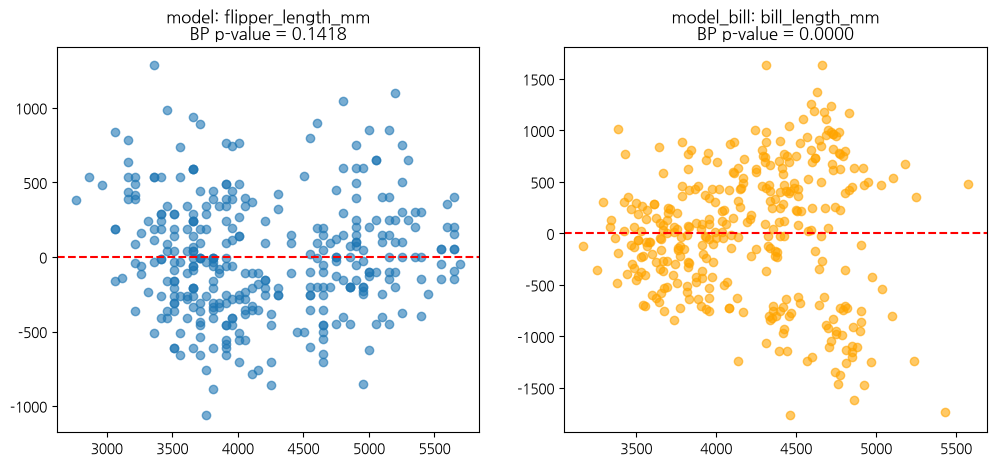

In [29]:
# 비교군
bill_data = penguins.dropna(subset=['body_mass_g', 'bill_length_mm'])
model_bill = smf.ols(formula='body_mass_g ~ bill_length_mm', data=bill_data).fit()

lm_stat1, lm_p1, f_stat1, f_p1 = het_breuschpagan(model.resid, model.model.exog)
lm_stat2, lm_p2, f_stat2, f_p2 = het_breuschpagan(model_bill.resid, model_bill.model.exog)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(model.fittedvalues, model.resid, alpha=0.6)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title(f"model: flipper_length_mm\nBP p-value = {lm_p1:.4f}")

ax[1].scatter(model_bill.fittedvalues, model_bill.resid, alpha=0.6, color='orange')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title(f"model_bill: bill_length_mm\nBP p-value = {lm_p2:.4f}")
plt.show()

Q6 · 보고 문장으로 정리해 봅시다

▸
지금까지의 결과를 종합해, 우리 회귀모형을 보고서에 어떻게 적을지 한 문장으로 쓰세요.

▸
기울기 + 유의성 + 설명력 + 진단 결과를 모두 담아 보세요.

코드보다는 지금까지의 모든 결과를 하나로 압축하는 문장을 쓰는 문제네요. 지금까지 확보한 숫자들을 모으면:

기울기(b) = 49.6856 (g/mm)

유의성: p ≈ 4.37×10⁻¹⁰⁷ (α=0.05에서 매우 유의)

설명력: R² = 0.759 (75.9%)

등분산성 진단: 브루쉬-페이건 p = 0.1418 → 등분산 가정 충족 (기각 실패)

보고 문장:

펭귄의 날개 길이(flipper_length_mm)를 이용해 몸무게(body_mass_g)를 예측하는 단순선형회귀모형을 적합한 결과, 

날개 길이가 1mm 증가할 때 몸무게는 평균적으로 약 49.69g 증가하는 것으로 나타났으며(p < .001), 

이 모형은 몸무게 변동의 약 75.9%(R² = 0.759)를 설명하였다. 브루쉬-페이건 검정 결과 잔차의 등분산성 가정이 위배되지 않아(p = 0.142), 

위 계수 추정치와 유의성 검정 결과는 신뢰할 수 있는 것으로 판단된다.

1) Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나? 문제 3·4 해석을 신뢰할 수 있는가?

Q3의 산점도에서 잔차는 예측값 전 구간에 걸쳐 0을 기준으로 고르게 흩어져 있었고, 특별한 깔때기 모양이나 곡선 패턴이 보이지 않았습니다. 

Q4의 브루쉬-페이건 검정(p = 0.1418)도 이를 뒷받침해, 등분산 가정을 기각할 근거가 없었습니다.

즉 정규성(관례상 확인하는 잔차 정규성) 및 등분산성 전제가 모두 무리 없이 충족된 것으로 보이므로, 

문제 3에서 구한 기울기(49.69g/mm)·R²(0.759)와 문제 4에서 내린 유의성 판정(p≈0, 기각)을 그대로 신뢰해도 좋습니다.

2) Q5의 두 잔차 산점도는 어떻게 달랐나? 이 모양을 뭐라 부르는가?

model(flipper_length_mm)은 잔차가 고르게 퍼져 있었던 반면, model_bill(bill_length_mm)은 BP p-value가 사실상 0으로 나올 만큼 등분산성이 깨져 있었습니다. 

이런 경우 잔차 산점도에서는 예측값이 커지거나 작아짐에 따라 흩어짐의 폭이 점점 벌어지는 모양이 나타나는데, 이를 강의에서 배운 용어로 깔때기(부채꼴) 모양 — 즉 이분산성(heteroscedasticity) 이라고 부릅니다.

3) 등분산성이 깨졌을 때, 잘못된 것은 기울기 값 자체인가, 통계적 해석인가?

통계적 해석(유의성·신뢰구간)과 예측 결과 쪽이 잘못될 위험이 있는 것이지, 기울기 추정값 자체(파라미터 point estimate)가 틀렸다는 뜻은 아닙니다. 

OLS 기울기 추정치는 등분산성이 깨져도 여전히 불편추정량이긴 하지만, 표준오차 계산이 등분산 가정 위에 세워져 있기 때문에 p-value와 신뢰구간이 왜곡됩니다. 

그래서 "숫자 자체는 맞을 수 있어도, 그 숫자를 근거로 '유의하다/신뢰구간이 이렇다'고 말하는 부분은 믿기 어려워진다"는 것이 정확한 표현입니다.

4) R²가 1이 아니다 — penguins에서 놓치고 있는 변수는?

문제 1의 그림에서 이미 만났던 종(species) 이 가장 유력한 후보입니다. Gentoo는 골격 자체가 크고 무거운 편이라, 

같은 날개 길이라도 종에 따라 몸무게가 체계적으로 다를 수 있습니다. 

그 외에도 성별(sex) — 보통 수컷이 암컷보다 크고 무거운 경향 — 도 놓치고 있는 요인일 가능성이 큽니다. 이런 변수들이 모델에 빠져 있으면, 

그 변수들이 설명했을 몫이 R²에 잡히지 않고 잔차(설명되지 않은 24.1%)로 남게 됩니다.

5) 그 변수들을 함께 넣으려면 어떤 분석이 필요한가?

설명변수가 여러 개(flipper_length_mm과 함께 species, sex 등)로 늘어나므로, 이는 다중회귀분석(Multiple Linear Regression) 이 필요합니다. 

body_mass_g ~ flipper_length_mm + C(species) + C(sex) 같은 형태로 모델을 확장하면, 종과 성별의 영향을 통제한 상태에서 날개 길이가 몸무게에 미치는 "순수한" 효과를 더 정확히 추정할 수 있습니다.